# 🔬 Glaucoma Detection — EfficientNetB4 Transfer Learning
**Dataset:** `train / validation / test` → `NRG` / `RG` subfolders  
**Train:** 4000 RG + 4000 NRG &nbsp;|&nbsp; **Val/Test:** 385 RG + 385 NRG each  

### Pipeline Overview
1. EDA — class distribution, sample images, pixel stats, resolution audit  
2. Preprocessing — CLAHE contrast enhancement  
3. Data Pipeline — `tf.data` with augmentation  
4. Model — EfficientNetB4 backbone + dual-pool head  
5. Two-Phase Training — frozen backbone → fine-tune top 40 layers  
6. Evaluation — confusion matrix, ROC, PR curve  

In [1]:
# ============================================================
# Glaucoma Detection — EfficientNetB4 | Kaggle Notebook
# Dataset: train/val/test → NRG / RG subfolders
# Train: 4000 RG + 4000 NRG
# Val:    385 RG +  385 NRG
# Test:   385 RG +  385 NRG
# ============================================================

## ⚙️ 0. Install & Imports

In [2]:
# ─── 0. Install / Imports ────────────────────────────────────────────────────
# !pip install -q scikit-learn matplotlib seaborn tensorflow

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.mixed_precision import set_global_policy
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
)
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

2026-04-06 02:08:37.672055: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775441317.698936     291 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775441317.708007     291 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775441317.730070     291 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775441317.730101     291 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775441317.730104     291 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📁 1. Paths & Configuration

In [3]:
# ─── 1. Paths & Config ───────────────────────────────────────────────────────────────────────────────────────

# ============================================================
# ✏️  SET YOUR DATASET PATHS HERE
# Each directory must contain two sub-folders: NRG/ and RG/
# ============================================================
TRAIN_DIR  = r"/kaggle/input/datasets/deathtrooper/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/train"        # ← change to your train folder
VAL_DIR    = r"/kaggle/input/datasets/deathtrooper/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation"   # ← change to your validation folder
TEST_DIR   = r"/kaggle/input/datasets/deathtrooper/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/test"         # ← change to your test folder

# Output directories (created automatically)
import os
OUTPUT_DIR     = os.path.join(os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() else os.getcwd(), "outputs")
CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
LOG_DIR        = os.path.join(OUTPUT_DIR, "logs")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# ─── Hyperparameters ─────────────────────────────────────────
CLASSES        = ["NRG", "RG"]          # 0 = NRG, 1 = RG
IMG_SIZE       = 380
BATCH_SIZE     = 64
NUM_CLASSES    = 2

EPOCHS_PHASE1  = 20
EPOCHS_PHASE2  = 30
LR_PHASE1      = 1e-3
LR_PHASE2      = 1e-5
WEIGHT_DECAY   = 1e-4
DROPOUT_RATE   = 0.5
UNFREEZE_LAYERS= 40

print(f"Train      : {TRAIN_DIR}")
print(f"Validation : {VAL_DIR}")
print(f"Test       : {TEST_DIR}")
print(f"Outputs    : {OUTPUT_DIR}")


Train      : /kaggle/input/datasets/deathtrooper/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/train
Validation : /kaggle/input/datasets/deathtrooper/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation
Test       : /kaggle/input/datasets/deathtrooper/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/test
Outputs    : /kaggle/working/outputs


## 📊 2. Exploratory Data Analysis (EDA)

In [4]:
# ─── 2. EDA ──────────────────────────────────────────────────────────────────

def count_images(root_dir):
    counts = {}
    for cls in CLASSES:
        path = os.path.join(root_dir, cls)
        counts[cls] = len(os.listdir(path)) if os.path.exists(path) else 0
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

print("\n── Dataset Distribution ──────────────────────────────")
df_dist = pd.DataFrame(
    {"Train": train_counts, "Validation": val_counts, "Test": test_counts}
)
print(df_dist)
print(f"\nTotal train : {sum(train_counts.values())}")
print(f"Total val   : {sum(val_counts.values())}")
print(f"Total test  : {sum(test_counts.values())}")


── Dataset Distribution ──────────────────────────────
     Train  Validation  Test
NRG   4000         385   385
RG    4000         385   385

Total train : 8000
Total val   : 770
Total test  : 770


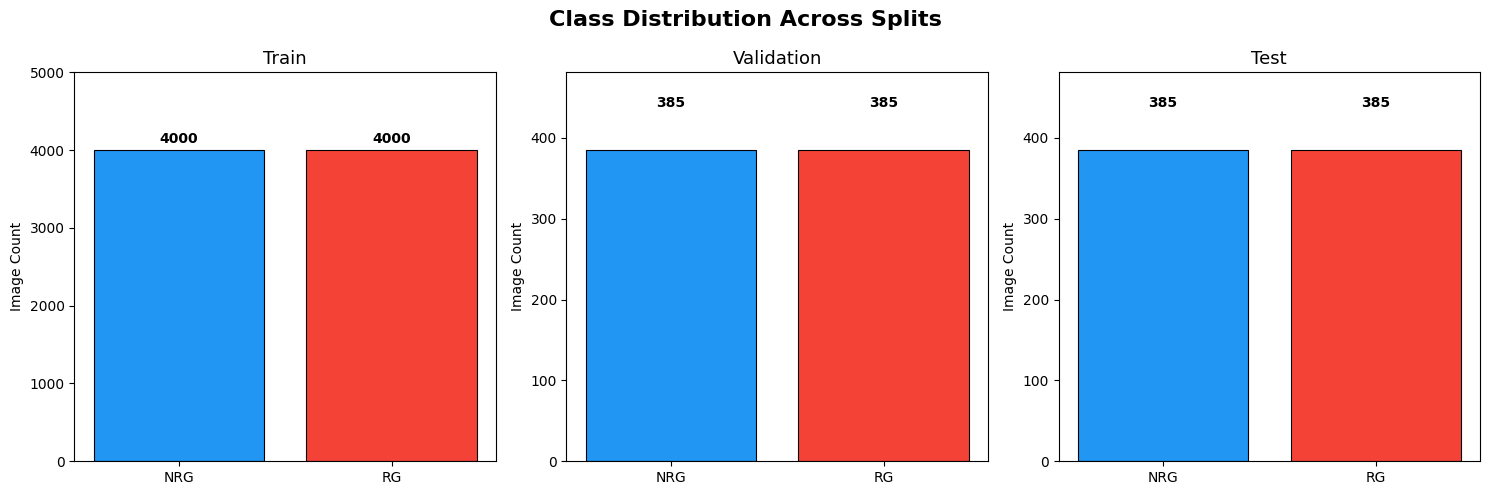

In [5]:
# ── 2a. Class Distribution Bar Chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Class Distribution Across Splits", fontsize=16, fontweight="bold")
colors = ["#2196F3", "#F44336"]

for ax, (split_name, counts) in zip(
    axes,
    [("Train", train_counts), ("Validation", val_counts), ("Test", test_counts)],
):
    bars = ax.bar(counts.keys(), counts.values(), color=colors, edgecolor="black", linewidth=0.8)
    ax.set_title(split_name, fontsize=13)
    ax.set_ylabel("Image Count")
    ax.set_ylim(0, max(counts.values()) * 1.25)
    for bar, val in zip(bars, counts.values()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            str(val), ha="center", va="bottom", fontweight="bold",
        )

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution.png", dpi=150)
plt.show()

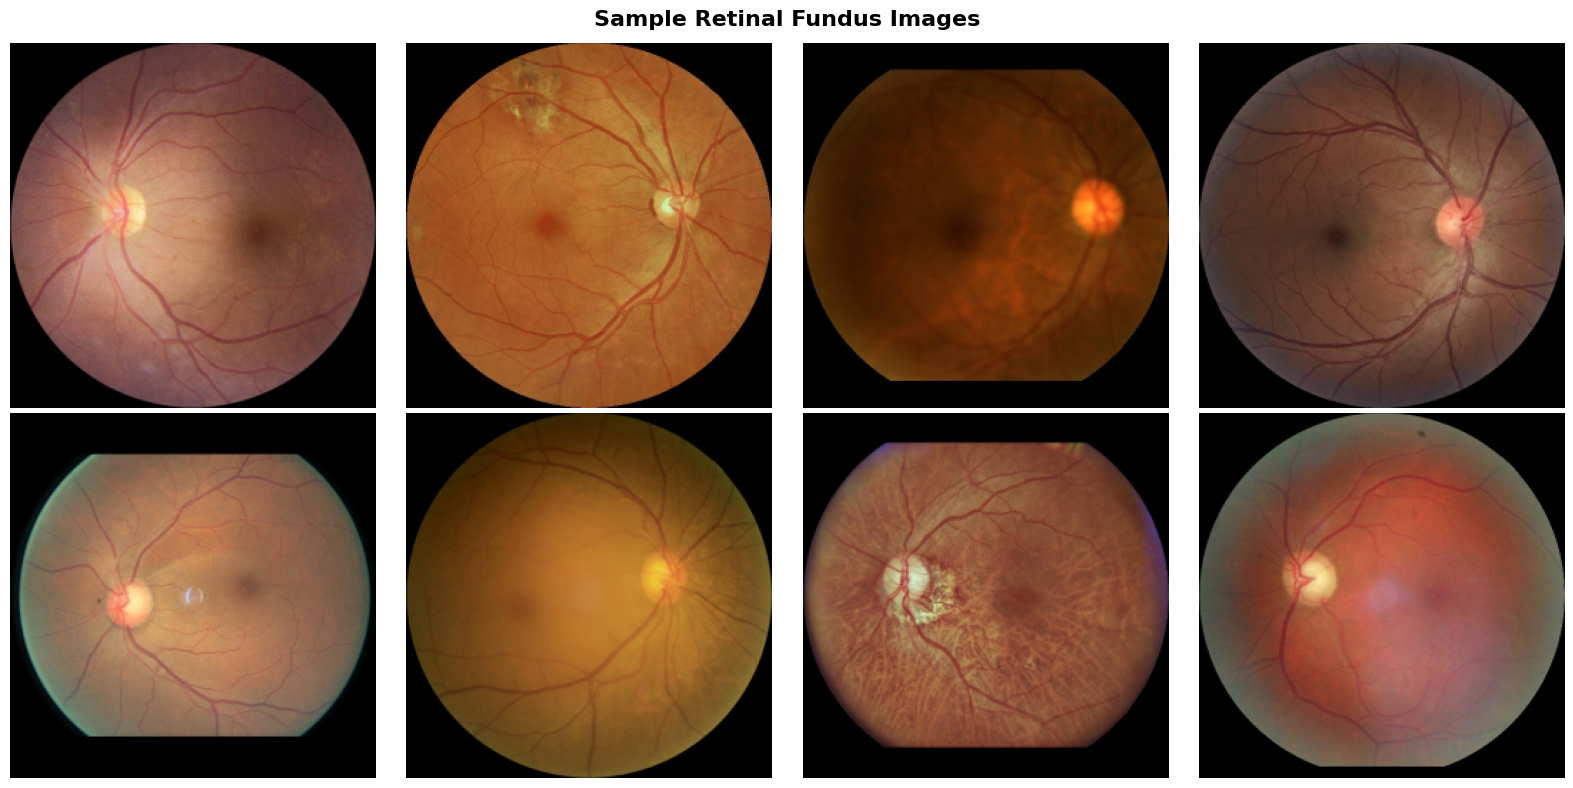

In [6]:
# ── 2b. Sample Images Grid ────────────────────────────────────────────────────
def load_sample_images(cls_dir, n=4):
    files = random.sample(os.listdir(cls_dir), min(n, len(os.listdir(cls_dir))))
    imgs = []
    for f in files:
        img = cv2.imread(os.path.join(cls_dir, f))
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (256, 256))
            imgs.append(img)
    return imgs

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Sample Retinal Fundus Images", fontsize=16, fontweight="bold")
titles = ["NRG (Non-Referable Glaucoma)", "RG (Referable Glaucoma)"]

for row, cls in enumerate(CLASSES):
    imgs = load_sample_images(os.path.join(TRAIN_DIR, cls), n=4)
    for col, img in enumerate(imgs[:4]):
        ax = axes[row][col]
        ax.imshow(img)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(titles[row], fontsize=11, fontweight="bold", labelpad=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sample_images.png", dpi=150)
plt.show()

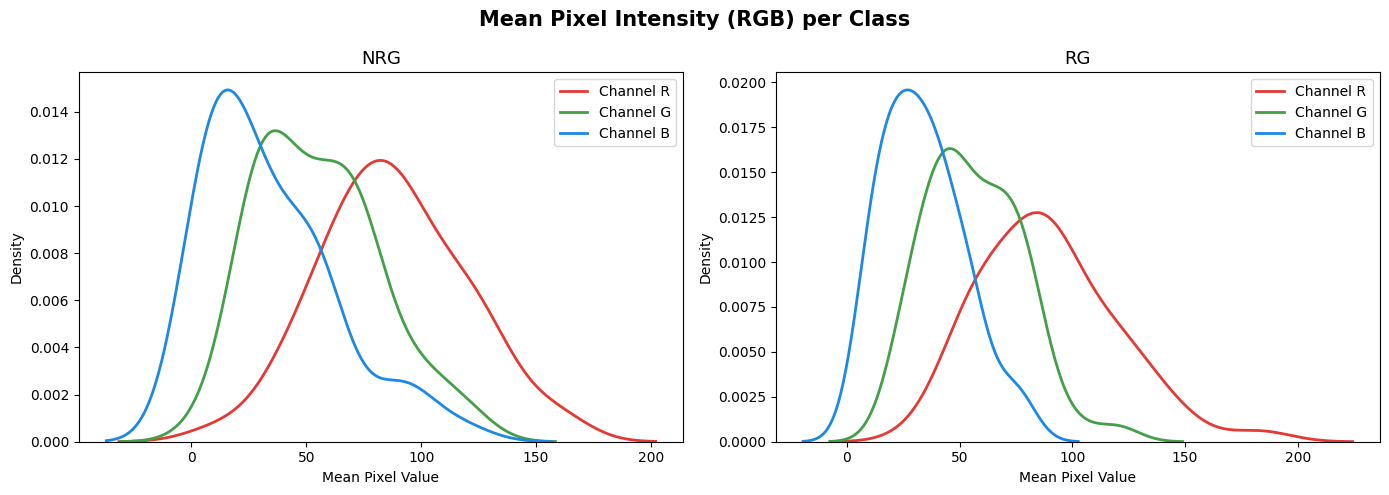

In [7]:
# ── 2c. Pixel Intensity Distribution ─────────────────────────────────────────
def get_mean_pixel_stats(cls_dir, n=50):
    files = random.sample(os.listdir(cls_dir), min(n, len(os.listdir(cls_dir))))
    all_means = {"R": [], "G": [], "B": []}
    for f in files:
        img = cv2.imread(os.path.join(cls_dir, f))
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (128, 128)).astype(np.float32)
            for i, ch in enumerate(["R", "G", "B"]):
                all_means[ch].append(img[:, :, i].mean())
    return all_means

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Mean Pixel Intensity (RGB) per Class", fontsize=15, fontweight="bold")
ch_colors = {"R": "#e53935", "G": "#43a047", "B": "#1e88e5"}

for ax, cls in zip(axes, CLASSES):
    stats = get_mean_pixel_stats(os.path.join(TRAIN_DIR, cls))
    for ch, vals in stats.items():
        sns.kdeplot(vals, ax=ax, label=f"Channel {ch}", color=ch_colors[ch], linewidth=2)
    ax.set_title(cls, fontsize=13)
    ax.set_xlabel("Mean Pixel Value")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pixel_intensity.png", dpi=150)
plt.show()

In [8]:
# ── 2d. Image Resolution Check ───────────────────────────────────────────────
def check_resolutions(cls_dir, n=100):
    files = random.sample(os.listdir(cls_dir), min(n, len(os.listdir(cls_dir))))
    shapes = []
    for f in files:
        img = cv2.imread(os.path.join(cls_dir, f))
        if img is not None:
            shapes.append(img.shape[:2])
    return shapes

print("\n── Resolution Samples (H x W) ────────────────────────")
for cls in CLASSES:
    shapes = check_resolutions(os.path.join(TRAIN_DIR, cls))
    unique = set(shapes)
    print(f"  {cls}: {len(unique)} unique resolutions — most common: "
          f"{max(set(shapes), key=shapes.count)}")


── Resolution Samples (H x W) ────────────────────────
  NRG: 1 unique resolutions — most common: (512, 512)
  RG: 1 unique resolutions — most common: (512, 512)


## 🖼️ 3. Preprocessing — CLAHE

In [9]:
# ─── 3. Preprocessing ────────────────────────────────────────────────────────
# Strategy:
#   • Apply CLAHE on the LAB L-channel (clinically relevant for optic disc)
#   • Resize to IMG_SIZE x IMG_SIZE
#   • EfficientNet preprocess_input normalises to [-1, 1]
# NOTE: image_dataset_from_directory yields BATCHES, so clahe_tf maps
#       over the batch dimension with tf.vectorized_map.

def apply_clahe_numpy(image_np):
    """CLAHE on LAB L-channel; input uint8 HxWx3 RGB, output float32 HxWx3."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab = cv2.cvtColor(image_np, cv2.COLOR_RGB2LAB)
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    result = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return result.astype(np.float32)

def clahe_single(image):
    """Apply CLAHE to a single image tensor (H, W, 3) float32."""
    def _fn(img):
        img_np = img.numpy().astype(np.uint8)
        return apply_clahe_numpy(img_np)
    out = tf.py_function(_fn, [image], tf.float32)
    out.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return out

def clahe_tf(images, labels):
    """Apply CLAHE to a batch of images via tf.vectorized_map."""
    images = tf.cast(images, tf.float32)
    # Process each image in the batch individually
    images = tf.map_fn(
        clahe_single,
        images,
        fn_output_signature=tf.TensorSpec(shape=[IMG_SIZE, IMG_SIZE, 3], dtype=tf.float32)
    )
    return images, labels


## 🔄 4. Data Pipeline & Augmentation

I0000 00:00:1775441332.351193     291 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 8000 files belonging to 2 classes.
Found 770 files belonging to 2 classes.
Found 770 files belonging to 2 classes.

Datasets built:
  Train batches : 125
  Val batches   : 13
  Test batches  : 13

Visualising augmentation on sample images...


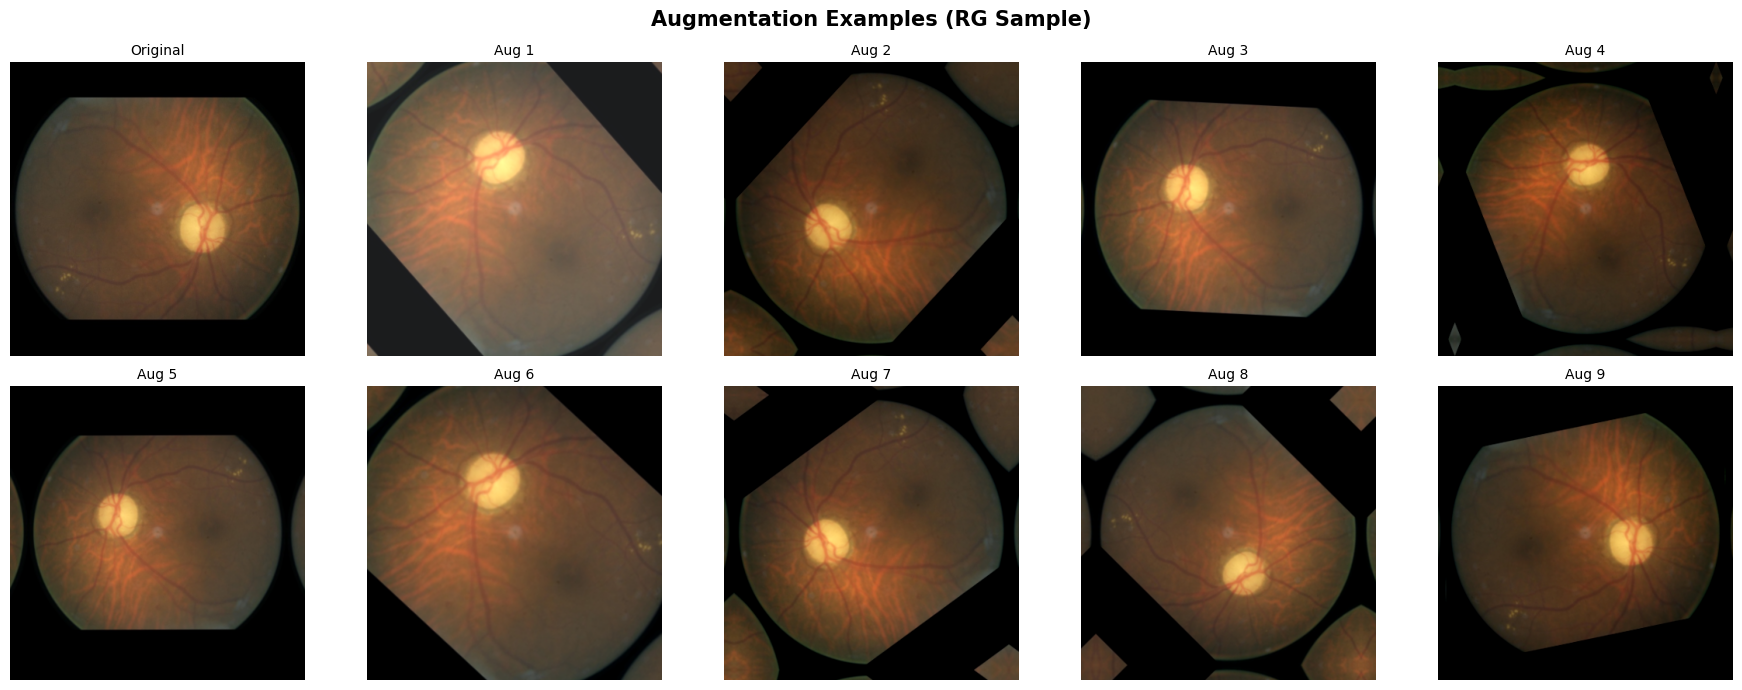

In [10]:
# ─── 4. Data Pipeline ────────────────────────────────────────────────────────

preprocess_fn = keras.applications.efficientnet.preprocess_input

augment_layer = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.20),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(0.1, 0.1),
], name="augmentation")


def build_dataset(directory, augment=False):
    ds = keras.utils.image_dataset_from_directory(
        directory,
        class_names=CLASSES,          # ensures NRG=0, RG=1
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode="categorical",
        shuffle=augment,
        seed=SEED,
    )

    # CLAHE preprocessing — operates on float32 batches
    ds = ds.map(clahe_tf, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def augment_and_preprocess(x, y):
            x = preprocess_fn(x)                          # normalize first
            x = tf.cast(x, tf.float32)                    # ensure float32 before aug
            x = augment_layer(x, training=True)
            return x, y
        ds = ds.map(augment_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(
            lambda x, y: (tf.cast(preprocess_fn(x), tf.float32), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    return ds.prefetch(tf.data.AUTOTUNE)


train_ds = build_dataset(TRAIN_DIR, augment=True)
val_ds   = build_dataset(VAL_DIR,   augment=False)
test_ds  = build_dataset(TEST_DIR,  augment=False)

print("\nDatasets built:")
print(f"  Train batches : {len(train_ds)}")
print(f"  Val batches   : {len(val_ds)}")
print(f"  Test batches  : {len(test_ds)}")

# ── 4a. Visualise Augmentations ─────────────────────────────────────────────
print("\nVisualising augmentation on sample images...")

sample_dir  = os.path.join(TRAIN_DIR, "RG")
sample_file = random.choice(os.listdir(sample_dir))
orig_img    = cv2.imread(os.path.join(sample_dir, sample_file))
orig_img    = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
orig_img    = cv2.resize(orig_img, (IMG_SIZE, IMG_SIZE))

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Augmentation Examples (RG Sample)", fontsize=15, fontweight="bold")
axes[0][0].imshow(orig_img)
axes[0][0].set_title("Original", fontsize=10)
axes[0][0].axis("off")

aug_only = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.20),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
])

inp = tf.expand_dims(tf.cast(orig_img, tf.float32), 0)
for idx in range(1, 10):
    row, col = divmod(idx, 5)
    aug_out = aug_only(inp, training=True)[0].numpy().astype(np.uint8)
    axes[row][col].imshow(aug_out)
    axes[row][col].set_title(f"Aug {idx}", fontsize=10)
    axes[row][col].axis("off")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/augmentation_preview.png", dpi=150)
plt.show()


## ⚖️ 5. Class Weights

In [11]:
# ─── 5. Class Weights ────────────────────────────────────────────────────────
# Dataset is balanced (4000 each) — weights = 1.0, but kept for extensibility
labels_train = np.array([0] * train_counts["NRG"] + [1] * train_counts["RG"])
cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=labels_train)
class_weights = {0: cw[0], 1: cw[1]}
print(f"\nClass weights: {class_weights}")


Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


## 🏗️ 6. Model Architecture — GlaucomaNet B4

In [12]:
# ─── 6. Model ────────────────────────────────────────────────────────────────

set_global_policy("mixed_float16")

def build_model():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")

    backbone = EfficientNetB4(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs,
        pooling=None,                                                                                                 
        name="efficientnetb4",
    )
    backbone.trainable = False

    x = backbone.output  # (None, 16, 16, 1792) for 512×512

    # Feature Refinement
    x = layers.BatchNormalization(name="bn_feat1")(x)
    x = layers.Conv2D(512, (1, 1), padding="same", use_bias=False,
                      kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
                      name="feat_conv")(x)
    x = layers.BatchNormalization(name="bn_feat2")(x)
    x = layers.Activation("relu", name="relu_feat")(x)
    x = layers.Dropout(0.2, name="drop_feat")(x)

    # Dual pooling
    gap = layers.GlobalAveragePooling2D(name="gap")(x)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(x)
    x = layers.Concatenate(name="pool_concat")([gap, gmp])  # 1024-d

    # Head
    x = layers.BatchNormalization(name="bn_h1")(x)
    x = layers.Dense(512, kernel_regularizer=regularizers.l2(WEIGHT_DECAY), name="d1")(x)
    x = layers.BatchNormalization(name="bn_h2")(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(DROPOUT_RATE, name="drop_h1")(x)

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(WEIGHT_DECAY), name="d2")(x)
    x = layers.BatchNormalization(name="bn_h3")(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.3, name="drop_h2")(x)

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(WEIGHT_DECAY), name="d3")(x)
    x = layers.BatchNormalization(name="bn_h4")(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.2, name="drop_h3")(x)

    x = layers.Dense(NUM_CLASSES, name="logits")(x)
    outputs = layers.Activation("softmax", dtype="float32", name="predictions")(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="GlaucomaNet_B4")


model = build_model()
model.summary()

# Params breakdown
total      = model.count_params()
trainable  = sum([tf.size(w).numpy() for w in model.trainable_weights])
frozen     = total - trainable
print(f"\nTotal params    : {total:,}")
print(f"Trainable params: {trainable:,}")
print(f"Frozen params   : {frozen:,}")

Model: "GlaucomaNet_B4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 380, 380,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 380, 380,  │          0 │ input_image[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 380, 380,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 380, 380,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 381, 381,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 190, 190,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 190, 190,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 190, 190,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 190, 190,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 190, 190,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 190, 190,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 190, 190,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 190, 190,  │      1,152 │ block1a_se_excit

 Total params: 19,297,505 (73.61 MB)

 Trainable params: 1,615,234 (6.16 MB)

 Non-trainable params: 17,682,271 (67.45 MB)


Total params    : 19,297,505
Trainable params: 1,615,234
Frozen params   : 17,682,271


In [13]:
print([layer.name for layer in model.layers if "efficient" in layer.name.lower()])

[]


## 🛠️ 7. Training Utilities (Callbacks & Metrics)

In [14]:
# ─── 7. Training Utilities ───────────────────────────────────────────────────

def get_callbacks(phase):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=f"{CHECKPOINT_DIR}/phase{phase}_best.keras",
            monitor="val_auc", mode="max",
            save_best_only=True, verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            patience=8 if phase == 1 else 10,
            restore_best_weights=True, verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=4, min_lr=1e-7, verbose=1,
        ),
        keras.callbacks.TensorBoard(
            log_dir=f"{LOG_DIR}/phase{phase}", histogram_freq=0,
        ),
        keras.callbacks.CSVLogger(
            f"{OUTPUT_DIR}/history_phase{phase}.csv",
        ),
    ]

METRICS = [
    "accuracy",
    keras.metrics.AUC(name="auc"),
    keras.metrics.Precision(name="precision"),
    keras.metrics.Recall(name="recall"),
]

## 🚀 8. Phase 1 — Train Classification Head (Backbone Frozen)

In [15]:
# ─── 8. Phase 1 — Train Head ─────────────────────────────────────────────────

print("\n" + "="*60)
print("PHASE 1 — Classification head (backbone frozen)")
print("="*60)

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR_PHASE1, weight_decay=WEIGHT_DECAY),
    loss="categorical_crossentropy",
    metrics=METRICS,
)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=get_callbacks(1),
    class_weight=class_weights,
)


PHASE 1 — Classification head (backbone frozen)
Epoch 1/20


I0000 00:00:1775441381.612754     358 service.cc:152] XLA service 0x3a01e790 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775441381.612797     358 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775441395.372781     358 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775441450.670143     358 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6280 - auc: 0.6832 - loss: 0.9054 - precision: 0.6280 - recall: 0.6280
Epoch 1: val_auc improved from -inf to 0.77396, saving model to /kaggle/working/outputs/checkpoints/phase1_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 413s 2s/step - accuracy: 0.6284 - auc: 0.6837 - loss: 0.9048 - precision: 0.6284 - recall: 0.6284 - val_accuracy: 0.6831 - val_auc: 0.7740 - val_loss: 0.8307 - val_precision: 0.6831 - val_recall: 0.6831 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7416 - auc: 0.8203 - loss: 0.7377 - precision: 0.7415 - recall: 0.7415
Epoch 2: val_auc improved from 0.77396 to 0.82523, saving model to /kaggle/working/outputs/checkpoints/phase1_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 239s 2s/step - accuracy: 0.7417 - auc: 0.8204 - loss: 0.7376 - precision: 0.7416 - recall: 0.7416 - val_accuracy: 0.7299 - val_auc: 0.8252 - val_loss: 0.7690 - val_precision: 0.7299 - val_recall: 0.7299 - learning_r

In [16]:
# ─── Load Phase 1 checkpoint to restore model ────────────────────────────────
import tensorflow as tf
from tensorflow import keras

model = keras.models.load_model(f"{CHECKPOINT_DIR}/phase1_best.keras")
print("✅ Model loaded from Phase 1 checkpoint")
print(f"Total params: {model.count_params():,}")

✅ Model loaded from Phase 1 checkpoint
Total params: 19,297,505


## 🔓 9. Phase 2 — Fine-Tune Top Backbone Layers

In [17]:
# ─── 9. Phase 2 — Fine-Tune ──────────────────────────────────────────────────
UNFREEZE_LAYERS = 40 
print("\n" + "="*60)
print(f"PHASE 2 — Fine-tuning top {UNFREEZE_LAYERS} backbone layers")
print("="*60)

# Backbone layers are flattened into the model directly (no sub-model wrapper)
# So we identify them by excluding our custom head layer names
custom_layer_names = {
    "bn_feat1", "feat_conv", "bn_feat2", "relu_feat", "drop_feat",
    "gap", "gmp", "pool_concat",
    "bn_h1", "d1", "bn_h2", "drop_h1",
    "d2", "bn_h3", "drop_h2",
    "d3", "bn_h4", "drop_h3",
    "logits", "predictions", "input_image"
}

backbone_layers = [
    l for l in model.layers
    if l.name not in custom_layer_names
    and not l.name.startswith("activation")
]

# Unfreeze all backbone layers first
for layer in backbone_layers:
    layer.trainable = True

# Freeze all except top UNFREEZE_LAYERS
for layer in backbone_layers[:-UNFREEZE_LAYERS]:
    layer.trainable = False

# Always keep BatchNormalization frozen
for layer in model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR_PHASE2, weight_decay=WEIGHT_DECAY),
    loss="categorical_crossentropy",
    metrics=METRICS,
)

trainable_p2 = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable params after unfreeze: {trainable_p2:,}")

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=get_callbacks(2),
    class_weight=class_weights,
)


PHASE 2 — Fine-tuning top 40 backbone layers
Trainable params after unfreeze: 7,528,090
Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8407 - auc: 0.9209 - loss: 0.4855 - precision: 0.8369 - recall: 0.8369
Epoch 1: val_auc improved from -inf to 0.93822, saving model to /kaggle/working/outputs/checkpoints/phase2_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 385s 2s/step - accuracy: 0.8408 - auc: 0.9209 - loss: 0.4854 - precision: 0.8369 - recall: 0.8369 - val_accuracy: 0.8649 - val_auc: 0.9382 - val_loss: 0.4495 - val_precision: 0.8649 - val_recall: 0.8649 - learning_rate: 1.0000e-05
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8555 - auc: 0.9313 - loss: 0.4646 - precision: 0.8555 - recall: 0.8555
Epoch 2: val_auc improved from 0.93822 to 0.94094, saving model to /kaggle/working/outputs/checkpoints/phase2_best.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.8555 - auc: 0.9313 - loss: 0.4646 - precision: 0.8555 - recall: 0.8555 - val_accurac

## 📈 10. Training Curves

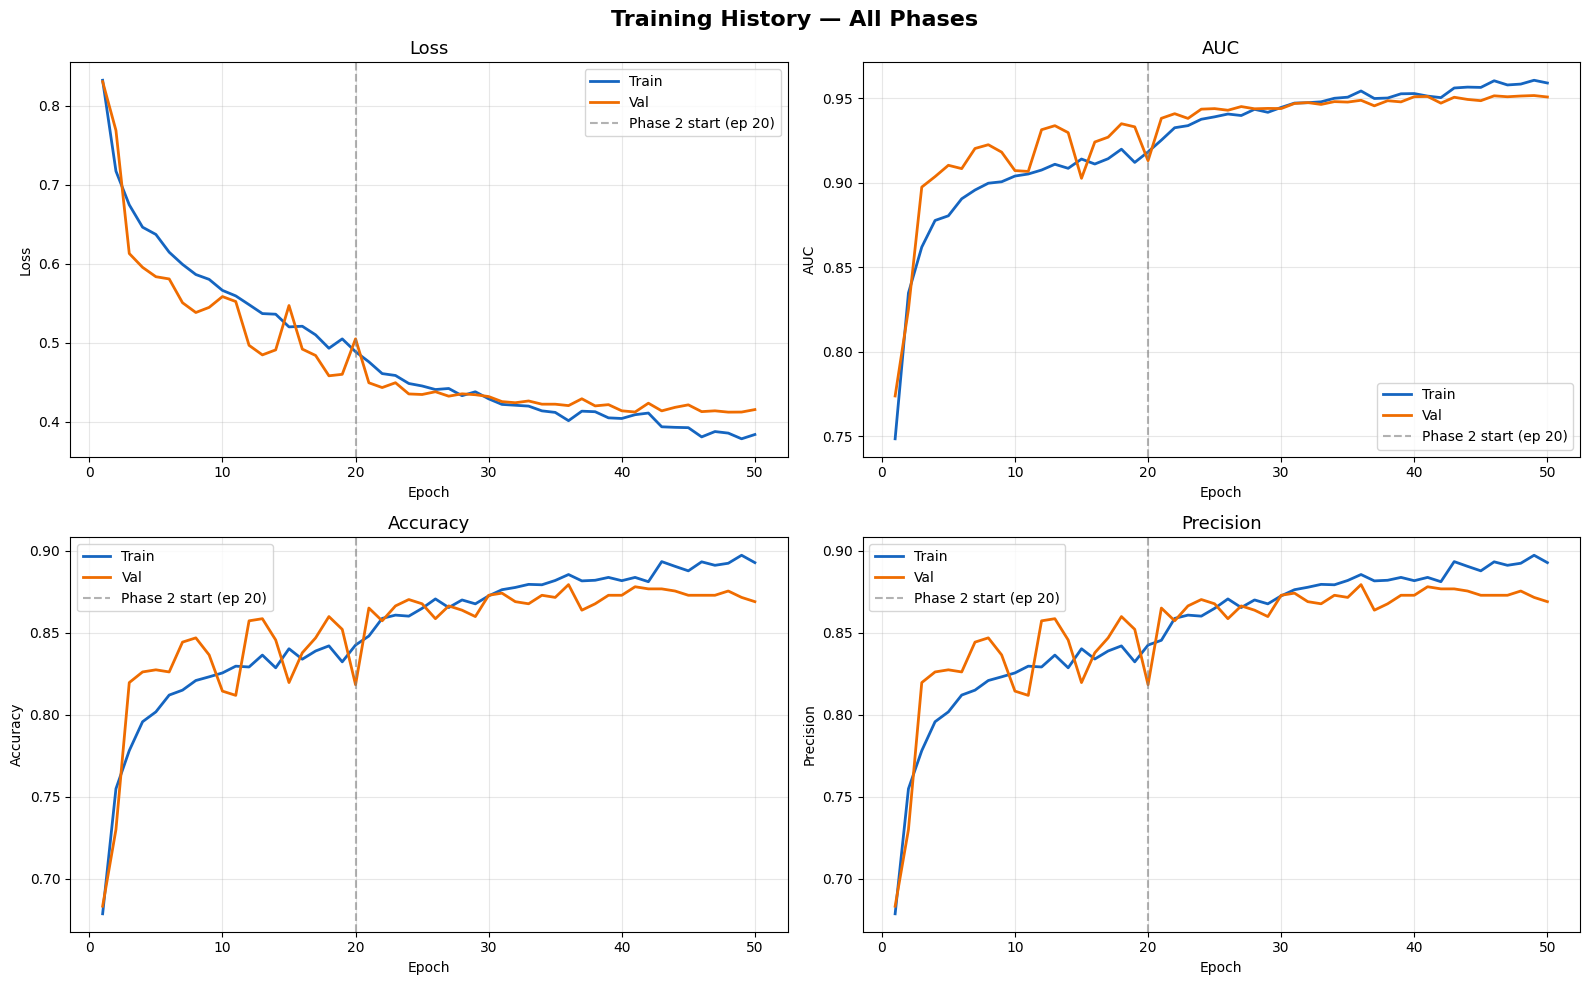

In [18]:
# ─── 10. Training Curves ─────────────────────────────────────────────────────

def merge_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

hist = merge_histories(history1, history2)
phase1_end = len(history1.history["loss"])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Training History — All Phases", fontsize=16, fontweight="bold")

metrics_to_plot = [
    ("loss",      "val_loss",      "Loss",      "Loss"),
    ("auc",       "val_auc",       "AUC",       "AUC"),
    ("accuracy",  "val_accuracy",  "Accuracy",  "Accuracy"),
    ("precision", "val_precision", "Precision", "Precision"),
]

for ax, (train_key, val_key, title, ylabel) in zip(axes.flat, metrics_to_plot):
    epochs = range(1, len(hist[train_key]) + 1)
    ax.plot(epochs, hist[train_key], label="Train", color="#1565C0", linewidth=2)
    ax.plot(epochs, hist[val_key],   label="Val",   color="#EF6C00", linewidth=2)
    ax.axvline(phase1_end, color="gray", linestyle="--", alpha=0.6, label=f"Phase 2 start (ep {phase1_end})")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150)
plt.show()

## 🧪 11. Evaluation on Test Set

In [19]:
# ─── 11. Evaluation ──────────────────────────────────────────────────────────

print("\n── Evaluating on Test Set ────────────────────────────")
results = model.evaluate(test_ds, verbose=1)
print("\nTest Results:")
for name, val in zip(model.metrics_names, results):
    print(f"  {name:12s}: {val:.4f}")

# Gather predictions
y_true, y_pred_prob = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_pred_prob.extend(preds[:, 1].tolist())
    y_true.extend(np.argmax(labels.numpy(), axis=1).tolist())

y_true      = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)
y_pred      = (y_pred_prob >= 0.5).astype(int)


── Evaluating on Test Set ────────────────────────────
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 489ms/step - accuracy: 0.8322 - auc: 0.9226 - loss: 0.5030 - precision: 0.8322 - recall: 0.8322

Test Results:
  loss        : 0.4699
  compile_metrics: 0.8519


In [20]:
# ── 11a. Classification Report ────────────────────────────────────────────────
print("\n── Classification Report ─────────────────────────────")
print(classification_report(y_true, y_pred, target_names=CLASSES))


── Classification Report ─────────────────────────────
              precision    recall  f1-score   support

         NRG       0.87      0.82      0.85       385
          RG       0.83      0.88      0.86       385

    accuracy                           0.85       770
   macro avg       0.85      0.85      0.85       770
weighted avg       0.85      0.85      0.85       770



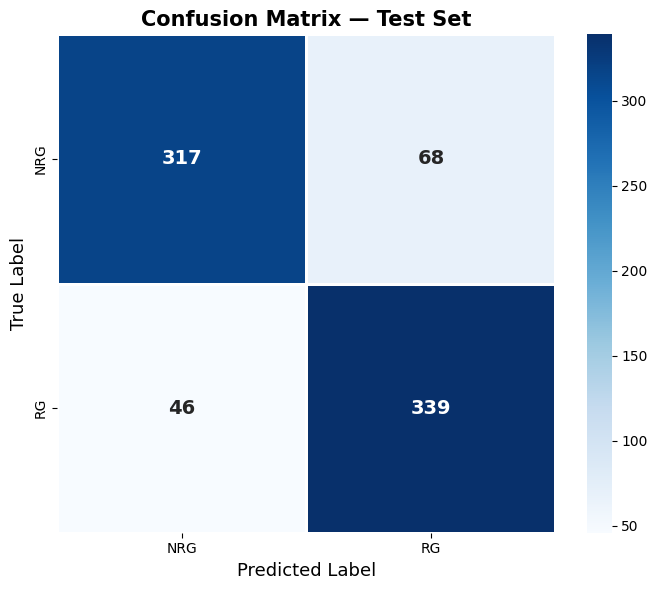

In [21]:
# ── 11b. Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES,
    linewidths=1, linecolor="white",
    annot_kws={"size": 14, "weight": "bold"},
)
ax.set_xlabel("Predicted Label", fontsize=13)
ax.set_ylabel("True Label", fontsize=13)
ax.set_title("Confusion Matrix — Test Set", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

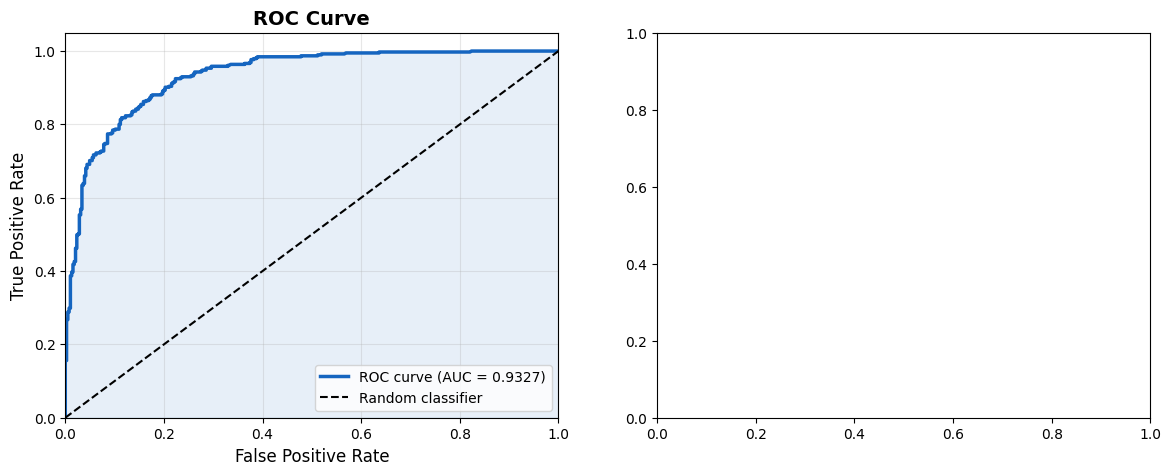

In [22]:
# ── 11c. ROC Curve ────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc_val = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color="#1565C0", lw=2.5,
             label=f"ROC curve (AUC = {roc_auc_val:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1.5, label="Random classifier")
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#1565C0")
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("False Positive Rate", fontsize=12)
axes[0].set_ylabel("True Positive Rate", fontsize=12)
axes[0].set_title("ROC Curve", fontsize=14, fontweight="bold")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

In [23]:
# ── 11d. Precision–Recall Curve ───────────────────────────────────────────────
prec, rec, _ = precision_recall_curve(y_true, y_pred_prob)
pr_auc_val   = auc(rec, prec)

axes[1].plot(rec, prec, color="#EF6C00", lw=2.5,
             label=f"PR curve (AUC = {pr_auc_val:.4f})")
axes[1].fill_between(rec, prec, alpha=0.1, color="#EF6C00")
axes[1].set_xlabel("Recall", fontsize=12)
axes[1].set_ylabel("Precision", fontsize=12)
axes[1].set_title("Precision–Recall Curve", fontsize=14, fontweight="bold")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_pr_curves.png", dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

## 💾 12. Save Model

In [24]:
# ─── 12. Save Model ──────────────────────────────────────────────────────────

model.save(f"{OUTPUT_DIR}/glaucoma_efficientnetb4_final.keras")
print(f"\nModel saved → {OUTPUT_DIR}/glaucoma_efficientnetb4_final.keras")

# Also export as SavedModel for TF Serving
model.export(f"{OUTPUT_DIR}/glaucoma_efficientnetb4_savedmodel")
print(f"SavedModel exported → {OUTPUT_DIR}/glaucoma_efficientnetb4_savedmodel")


Model saved → /kaggle/working/outputs/glaucoma_efficientnetb4_final.keras
INFO:tensorflow:Assets written to: /kaggle/working/outputs/glaucoma_efficientnetb4_savedmodel/assets


INFO:tensorflow:Assets written to: /kaggle/working/outputs/glaucoma_efficientnetb4_savedmodel/assets


Saved artifact at '/kaggle/working/outputs/glaucoma_efficientnetb4_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 380, 380, 3), dtype=tf.float32, name='input_image')]
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  133807900050256: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  133813391481872: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  133810114857488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133813391486672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133813391485712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133813391482448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133813391483408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133813391483024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133813391486288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133813391483984: Te

## 🏁 13. Final Summary

In [25]:
# ─── 13. Summary Card ─────────────────────────────────────────────────────────

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"  Test Accuracy  : {results[1]:.4f}")
print(f"  Test AUC       : {results[2]:.4f}")
print(f"  Test Precision : {results[3]:.4f}")
print(f"  Test Recall    : {results[4]:.4f}")
print(f"  ROC-AUC        : {roc_auc_val:.4f}")
print(f"  PR-AUC         : {pr_auc_val:.4f}")
print("="*60)
print(f"\nOutputs saved to {OUTPUT_DIR}/")
print("  ├── glaucoma_efficientnetb4_final.keras")
print("  ├── glaucoma_efficientnetb4_savedmodel/")
print("  ├── checkpoints/phase1_best.keras")
print("  ├── checkpoints/phase2_best.keras")
print("  ├── history_phase1.csv  &  history_phase2.csv")
print("  ├── class_distribution.png")
print("  ├── sample_images.png")
print("  ├── pixel_intensity.png")
print("  ├── augmentation_preview.png")
print("  ├── training_curves.png")
print("  ├── confusion_matrix.png")
print("  └── roc_pr_curves.png")


FINAL SUMMARY
  Test Accuracy  : 0.8519
  Test AUC       : 0.9326
  Test Precision : 0.8519
  Test Recall    : 0.8519
  ROC-AUC        : 0.9327
  PR-AUC         : 0.9296

Outputs saved to /kaggle/working/outputs/
  ├── glaucoma_efficientnetb4_final.keras
  ├── glaucoma_efficientnetb4_savedmodel/
  ├── checkpoints/phase1_best.keras
  ├── checkpoints/phase2_best.keras
  ├── history_phase1.csv  &  history_phase2.csv
  ├── class_distribution.png
  ├── sample_images.png
  ├── pixel_intensity.png
  ├── augmentation_preview.png
  ├── training_curves.png
  ├── confusion_matrix.png
  └── roc_pr_curves.png
